In [1]:
import os
import sys
import time
import glob
import argparse
import traceback

import json
import h5py
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors


from scipy.fft import rfft, rfftfreq
from scipy.stats import beta

In [2]:
# ----------------------------- #
#         Global Constants      #
# ----------------------------- #

SAMPLE_RATE = 0.016  # us per sample
adc14_max = 8191
adc14_16 = 2**2      # Conversion factor between 14 and 16 bit ADC

ADC_V_range = 2.0    # Voltage range of ADC
ADC_V_offset = -1.0  # Voltage offset
MAX_GIG = 2         # Maximum number of gigabytes allowed in the hdf5 file
rwm_channel = [16]
rwm_threshold = 10000

In [3]:
filename = '/global/cfs/cdirs/dune/users/ajwhite/FLOW_122025/Run1_July10_v12_JuneEvBuilderFlow_files/mpd_run_hvramp_rctl_105_p0.FLOW.hdf5'

In [4]:
try:
    #### DEFINE NUMBER OF GB TO KEEP IN args.max_gb ####
    input_file = h5py.File(filename, 'r')
    ## keep opened data below XXX GB to avoid crashes ##
    size_bytes = os.path.getsize(filename)
    size_gb = size_bytes / (1024 ** 3)
    print(f"File size: {size_gb:.2f} GB")

    MULT = int(size_gb // MAX_GIG)
    if MULT < 1:
        MULT = 1
    print(f"Using MULT = {MULT} for data reduction.")
    print(f"File opened successfully: {filename}")
except Exception as e:
    print(f"Error opening {filename}: {e}")
    #continue

File size: 4.18 GB
Using MULT = 2 for data reduction.
File opened successfully: /global/cfs/cdirs/dune/users/ajwhite/FLOW_122025/Run1_July10_v12_JuneEvBuilderFlow_files/mpd_run_hvramp_rctl_105_p0.FLOW.hdf5


In [5]:
print(input_file.keys())

#print(np.unique(input_file['light/events/data']['trig_type']))
beam_mask = (input_file['light/events/data']['trig_type']==1)
timestamps = input_file['light/events/data']['tai_ns'][:,0]
file_length = (np.max(timestamps) - np.min(timestamps)) / 1e9
time_differences = timestamps[1:] - timestamps[:-1]
print(file_length)
print(f"File length: {file_length:.2f} seconds")
print(f"Total Number of Events: {len(beam_mask):.2f} events")
print(f"Total Number of Beam Events: {np.sum(beam_mask):.2f} events")
print(f"Total Number of Off-Beam Events: {np.sum(beam_mask==0):.2f} events")
print(f"Beam Trigger Rate: {(np.sum(beam_mask)/file_length):.2f} Hz")
print(f"Self-Trigger Rate: {(np.sum(beam_mask==0)/file_length):.2f} Hz")
smallest_time_differences = time_differences[time_differences/1e3 < 5e5]
print(f"Minimum Dead Time: {(np.min(time_differences/1e3)):.2f} μs")

#print(input_file['light/wvfm/data'].dtype.names)
#beam_clipped = input_file['light/wvfm/data']['clipped'].sum(axis=-1)[beam_mask==1]
#offbeam_clipped = input_file['light/wvfm/data']['clipped'].sum(axis=-1)[beam_mask==0]
#print(input_file['light/wvfm/data']['clipped'].sum(axis=-1).shape)

<KeysViewHDF5 ['light']>
300.140381696
File length: 300.14 seconds
Total Number of Events: 4382.00 events
Total Number of Beam Events: 250.00 events
Total Number of Off-Beam Events: 4132.00 events
Beam Trigger Rate: 0.83 Hz
Self-Trigger Rate: 13.77 Hz
Minimum Dead Time: 454.91 μs


In [45]:
sipm_channels = ([4,5,6,7,8,9] + \
                     [10,11,12,13,14,15] + \
                     [20,21,22,23,24,25] + \
                     [26,27,28,29,30,31] + \
                     [36,37,38,39,40,41] + \
                     [42,43,44,45,46,47] + \
                     [52,53,54,55,56,57] + \
                     [58,59,60,61,62,63])

waveforms = input_file['light/wvfm/data']['samples'][:,:,:,75:125].max(axis=-1)
noise = input_file['light/wvfm/data']['samples'][:,:,:,0:50].max(axis=-1)

signal_mask_1 = (waveforms > (noise + 250))
signal_mask = signal_mask_1 + 1
#signal_mask[signal_mask == 0] = 1

In [46]:
print(waveforms[beam_mask==0][1302,4,:])
print(noise[beam_mask==0][1302,4,:])
print(waveforms[beam_mask==0][1302,4,:] - noise[beam_mask==0][1302,4,:])
cosmics_mask_l1 = (waveforms[beam_mask==0] > (noise[beam_mask==0] + 250))
#print(cosmics_mask_l1[0])
cosmics_mask_l2 = np.sum(cosmics_mask_l1, axis=-1)
print(cosmics_mask_l2[1302])
cosmics_mask_l3 = cosmics_mask_l2.sum(axis=-1)

cosmics_rate = np.sum(cosmics_mask_l3 >= 2) / (file_length - 2.5)
cosmics_mask = (cosmics_mask_l3 >= 2)
print(f"Cosmics Rate: {(cosmics_rate):.2f} Hz")
print(f"Number of Cosmics: {(np.sum(cosmics_mask_l3 >= 2)):.2f}")

[     0      0      0      0 -28272 -28224 -28676 -28252 -28888 -28532
 -29056 -27888 -27844 -28656 -27664 -28692      0      0      0      0
 -28584 -27252 -28076 -28416 -28264 -27936 -28456 -28272 -27844 -27912
 -28716 -28452      0      0      0      0 -28232 -28496 -28440 -28456
 -28324 -27536 -28168 -27544 -28028 -27584 -28792 -27844      0      0
      0      0 -28228 -28300 -28356 -27776 -27844 -27872 -28608 -28368
 -28952 -28376 -28036 -28300]
[     0      0      0      0 -28280 -28240 -28692 -28256 -28884 -28520
 -29064 -27900 -27844 -28656 -27684 -28692      0      0      0      0
 -28588 -27264 -28084 -28428 -28248 -27936 -28468 -28304 -27852 -27940
 -28700 -28472      0      0      0      0 -28240 -28472 -28448 -28464
 -28324 -27536 -28152 -27544 -28024 -27576 -28804 -27832      0      0
      0      0 -28232 -28648 -28380 -27760 -28740 -28400 -28608 -28368
 -28940 -28384 -28040 -28304]
[  0   0   0   0   8  16  16   4  -4 -12   8  12   0   0  20   0   0   0
   0   0   4  1

In [47]:
fraction_beam_signal = ((signal_mask_1[beam_mask==1][:,:,sipm_channels].sum(axis=-1)) > 1).sum(axis=0) / np.sum(beam_mask)
fraction_offbeam_signal = ((signal_mask_1[beam_mask==0][cosmics_mask==1][:,:,sipm_channels].sum(axis=-1)) > 1).sum(axis=0) / np.sum(beam_mask==0)

print(f"Average Fraction of Beam Events with Signal: {np.round(fraction_beam_signal,2)}")
print(f"Average Fraction of Off-Beam Events with Signal: {np.round(fraction_offbeam_signal, 2)}")

Average Fraction of Beam Events with Signal: [0.02 0.04 0.07 0.06 0.09 0.07 0.08 0.09]
Average Fraction of Off-Beam Events with Signal: [0.   0.   0.01 0.   0.03 0.01 0.   0.01]


In [48]:
clipped = input_file['light/wvfm/data']['clipped']

ratios_clip2sig_beam = (clipped[beam_mask==1]).sum(axis=0) / (signal_mask[beam_mask==1]).sum(axis=0)
ratios_clip2sig_offbeam = (clipped[beam_mask==0][cosmics_mask==1]).sum(axis=0) / (signal_mask[beam_mask==0][cosmics_mask==1]).sum(axis=0)



In [49]:
def plot_channels(spectrums, title, channel_status):

    metric = spectrums#[:,:,freq_idx]
    #min_nonzero = np.mean(metric[metric > 0].min(axis=-1))
    #metric[metric == 0] = min_nonzero
    figure = plt.figure(figsize=(18, 4))
    # color map
    cmap = plt.colormaps['viridis']
    cmap.set_bad(color='w')
    norm = mcolors.Normalize(vmin=0, vmax=1)
    plt.imshow(metric, cmap=cmap, aspect='auto', norm=LogNorm(vmin=1e-3, vmax=1))
    plt.colorbar(label='Clipping Fraction', shrink=0.9, pad=0.02)
    # Gridlines
    plt.xticks(np.arange(0, 64, 1)-0.5, labels=np.arange(0, 64, 1))
    plt.yticks(np.arange(0, 8, 1)-0.5, labels=np.arange(0, 8, 1))
    plt.xlabel('Channel', fontsize=14)
    plt.ylabel('ADC', fontsize=14)
    plt.grid(which='both', linewidth=0.5, alpha=0.5, color='white')

    # Add markers for channel_status == 1 and channel_status == 2
    y, x = np.where(channel_status!=0)
    plt.scatter(x, y, color='red', marker='o', edgecolors='w')
    y, x = np.where(channel_status==0)
    plt.scatter(x, y, color='w', marker='o', edgecolors='k')

    #plt.legend(loc='upper right')
    plt.title(f'2x2: {title} Clipping to Signal Fraction (1 File)', fontsize=16)
    plt.tight_layout()
    plt.show()

In [50]:
df = pd.read_csv("/global/cfs/cdirs/dune/users/ajwhite/2x2_LRS_DataAssess/Commissioning_Code/2x2_LRS_OperatingScripts/LowLevel_Commissioning/channel_status.csv", header=None)
channel_status = df.values

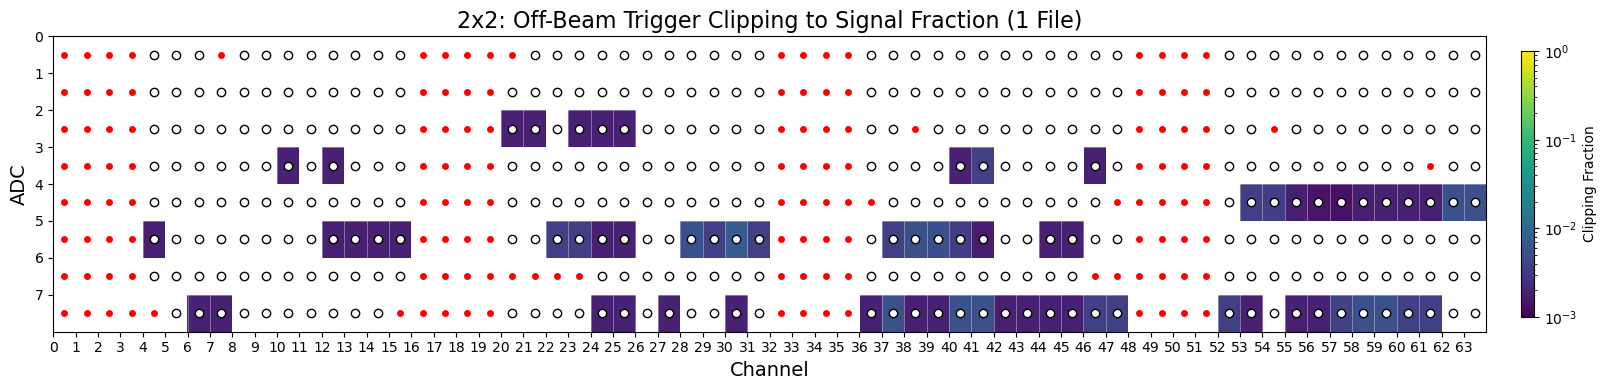

In [51]:
plot_channels(ratios_clip2sig_offbeam, 'Off-Beam Trigger', channel_status)

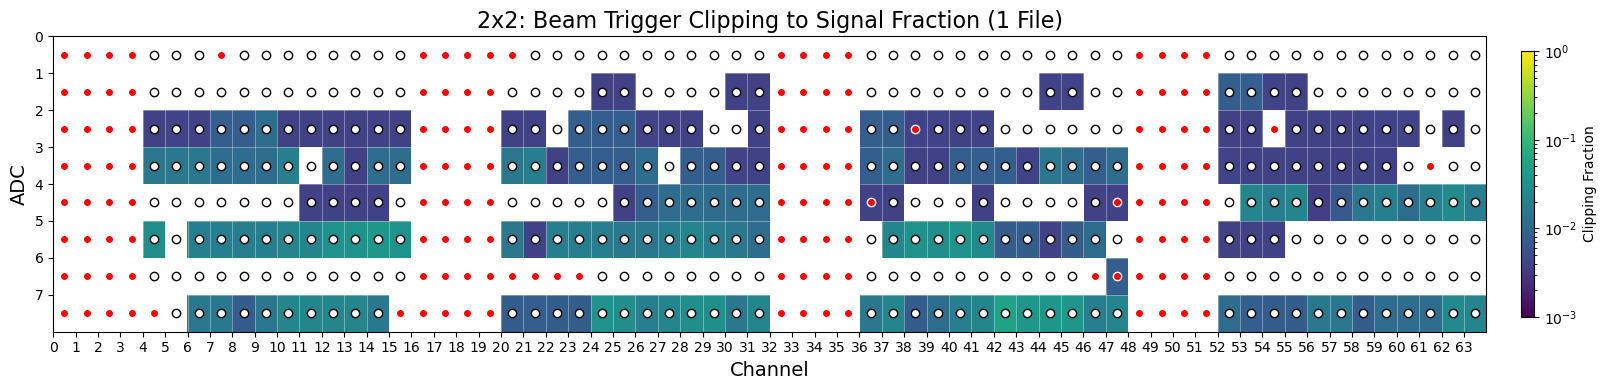

In [52]:
plot_channels(ratios_clip2sig_beam, 'Beam Trigger', channel_status)

In [53]:
print("Average Rate of Beam Clipping per Channel:", np.round(ratios_clip2sig_beam[:,sipm_channels].mean(axis=-1), 3)*100, "%")
print("Average Rate of Off-Beam Clipping per Channel:", np.round(ratios_clip2sig_offbeam[:,sipm_channels].mean(axis=-1), 3)*100, "%")

Average Rate of Beam Clipping per Channel: [0.  0.1 0.4 0.8 0.6 1.5 0.  1.8] %
Average Rate of Off-Beam Clipping per Channel: [0.  0.  0.  0.  0.1 0.1 0.  0.2] %


In [54]:
adc_signal = (signal_mask.sum(axis=-1) > 1)
adc_clipped = (clipped.sum(axis=-1) >= 1)

adc_ratios_clip2sig_beam = (adc_clipped[beam_mask==1]).sum(axis=0) / (adc_signal[beam_mask==1]).sum(axis=0)
adc_ratios_clip2sig_offbeam = (adc_clipped[beam_mask==0][cosmics_mask==1]).sum(axis=0) / (adc_signal[beam_mask==0][cosmics_mask==1]).sum(axis=0)

print("Average Rate of Beam Clipping per ADC:", np.round(adc_ratios_clip2sig_beam, 3)*100, "%")
print("Average Rate of Off-Beam Clipping per ADC:", np.round(adc_ratios_clip2sig_offbeam, 3)*100, "%")

Average Rate of Beam Clipping per ADC: [ 0.   2.   2.4 10.  10.4 17.2  0.8 20.8] %
Average Rate of Off-Beam Clipping per ADC: [0.  0.  0.2 0.8 1.7 2.4 0.  3. ] %
